## SQL Analysis - Churn as a Dynamic System

The physics model tells you who will churn and why. 
This SQL analysis answers the upstream question: where is the problem, how big is it, and which segments should we prioritize?

-> All queries use DuckDB: runs in-process, no server needed, same SQL dialect as Snowflake / BigQuery / Redshift with minor adaptations. 

### Setup

In [17]:
import duckdb
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mtick

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.visualization_static import PALETTE, set_style

set_style()

os.makedirs('exports', exist_ok=True)

RAW_PATH = '../data/telco_churn.csv'

try:
    raw = pd.read_csv(RAW_PATH)
    raw['TotalCharges'] = pd.to_numeric(raw['TotalCharges'], errors='coerce')
    raw['TotalCharges'].fillna(raw['MonthlyCharges'], inplace=True)
    raw['Churn_bin'] = (raw['Churn'] == 'Yes').astype(int)
    raw = raw.drop_duplicates(subset='customerID')
    # Compute num_services from individual service columns 
    svc_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    raw['num_services'] = sum((raw[c] == 'Yes').astype(int) for c in svc_cols if c in raw.columns)
    print(f'Real dataset: {len(raw):,} customers')
    USING_REAL_DATA = True

except FileNotFoundError:
    # Synthetic fallback, same structure as the real dataset
    rng = np.random.default_rng(42)
    n = 7043
    contracts = rng.choice(['Month-to-month','One year','Two year'], n, p=[0.55,0.25,0.20])
    payments = rng.choice(['Bank transfer (automatic)','Credit card (automatic)', 'Electronic check','Mailed check'], n, p=[0.22,0.22,0.33,0.23])
    tenure = rng.integers(0, 73, n)
    monthly = rng.uniform(20, 110, n).round(2)
    internet = rng.choice(['DSL','Fiber optic','No'], n, p=[0.34,0.44,0.22])
    n_services= rng.integers(0, 9, n)
    churn_p = np.where(contracts=='Month-to-month', 0.43,  np.where(contracts=='One year', 0.11, 0.03))
    churn_b = (rng.random(n) < churn_p).astype(int)
    raw = pd.DataFrame({
        'customerID': [f'C{i:06d}' for i in range(n)],
        'tenure': tenure,
        'MonthlyCharges':monthly,
        'TotalCharges': (monthly * np.maximum(tenure, 1)).round(2),
        'Contract': contracts,
        'PaymentMethod': payments,
        'InternetService': internet,
        'Churn': np.where(churn_b==1,'Yes','No'),
        'Churn_bin': churn_b,
        'num_services':  n_services,
        'SeniorCitizen': rng.integers(0, 2, n),})
    USING_REAL_DATA = False
    print(f'Synthetic dataset: {len(raw):,} customers (real data not found at {RAW_PATH})')

# Register in DuckDB
con = duckdb.connect()
con.register('customers', raw)
print(f'Columns: {raw.columns.tolist()}')
print(f'Churn rate: {raw["Churn_bin"].mean():.1%}')

Real dataset: 7,043 customers
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_bin', 'num_services']
Churn rate: 26.5%


### Churn Rate by Contract Type

-> Business question: Which contract type drives most of the churn? Where should retention focus first?

-> Decision: Budget allocation between contract migration campaigns (moving customers from month-to-month to annual) vs direct retention offers.

      Contract  n_customers  n_churned  churn_rate_pct  avg_monthly_charges  monthly_revenue_lost  six_month_revenue_lost
Month-to-month         3875     1655.0            42.7                66.40              120847.0                725083.0
      One year         1473      166.0            11.3                65.05               14118.0                 84711.0
      Two year         1695       48.0             2.8                60.77                4165.0                 24992.0


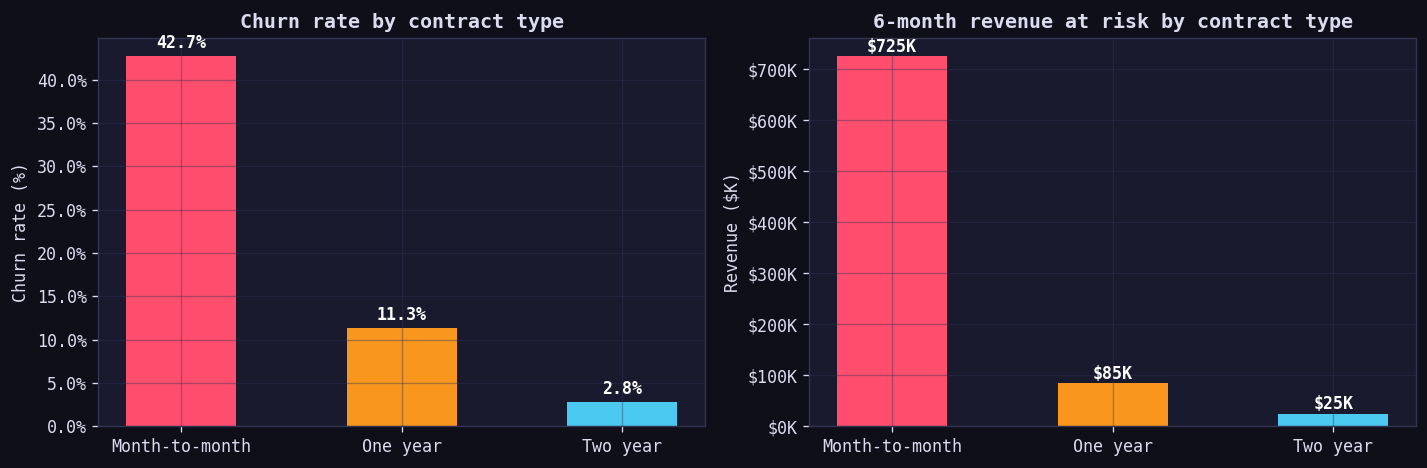

In [18]:
q_contract = """
SELECT
    Contract,
    COUNT(*) AS n_customers,
    SUM(Churn_bin) AS n_churned,
    ROUND(AVG(Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(SUM(Churn_bin * MonthlyCharges), 0) AS monthly_revenue_lost,
    ROUND(SUM(Churn_bin * MonthlyCharges) * 6, 0) AS six_month_revenue_lost
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC"""

df_contract = con.execute(q_contract).df()
print(df_contract.to_string(index=False))

# Chart 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [PALETTE['churn'], PALETTE['accent'], PALETTE['no_churn']]
axes[0].bar(df_contract['Contract'], df_contract['churn_rate_pct'], color=colors, edgecolor='none', width=0.5)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title('Churn rate by contract type', fontweight='bold')
axes[0].set_ylabel('Churn rate (%)')
for bar, val in zip(axes[0].patches, df_contract['churn_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')

axes[1].bar(df_contract['Contract'], df_contract['six_month_revenue_lost'] / 1000, color=colors, edgecolor='none', width=0.5)
axes[1].set_title('6-month revenue at risk by contract type', fontweight='bold')
axes[1].set_ylabel('Revenue ($K)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
for bar, val in zip(axes[1].patches, df_contract['six_month_revenue_lost']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'${val/1000:.0f}K', ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('exports/01_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

### Revenue at Risk - Customer Lifetime Value at Stake

-> Business question: Of the revenue currently at risk, how much is concentrated in which segments?

-> Decision it informs: Which segment deserves the highest retention investment. A customer paying $100/month who's at 80% churn risk is worth more to save than one paying $30/month at 60% risk.

In [19]:
q_revenue_risk = """
WITH customer_risk AS (
    SELECT
        customerID,
        Contract,
        MonthlyCharges,
        tenure,
        Churn_bin,
        -- Expected revenue lost = P(churn) × monthly × 6 months
        -- We use actual churn as a proxy for P(churn) in historical data
        Churn_bin * MonthlyCharges * 6 AS revenue_at_risk_6m,
        CASE
            WHEN MonthlyCharges >= 80 THEN 'High value (>=$80/mo)'
            WHEN MonthlyCharges >= 50 THEN 'Mid value ($50-$80/mo)'
            ELSE 'Low value (<$50/mo)'
        END AS value_tier
    FROM customers)

SELECT
    value_tier,
    COUNT(*) AS n_customers,
    SUM(Churn_bin) AS n_at_risk,
    ROUND(AVG(Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(SUM(revenue_at_risk_6m), 0) AS total_revenue_at_risk,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
    ROUND(SUM(revenue_at_risk_6m)
          / SUM(SUM(revenue_at_risk_6m)) OVER () * 100, 1) AS pct_of_total_risk
FROM customer_risk
GROUP BY value_tier
ORDER BY total_revenue_at_risk DESC"""

df_rev = con.execute(q_revenue_risk).df()
print(df_rev.to_string(index=False))
print(f"\nTotal revenue at risk (6m): ${df_rev['total_revenue_at_risk'].sum():,.0f}")

            value_tier  n_customers  n_at_risk  churn_rate_pct  total_revenue_at_risk  avg_monthly  pct_of_total_risk
 High value (>=$80/mo)         2677      910.0            34.0               514016.0        95.36               61.6
Mid value ($50-$80/mo)         2072      598.0            28.9               248104.0        66.55               29.7
   Low value (<$50/mo)         2294      361.0            15.7                72665.0        27.44                8.7

Total revenue at risk (6m): $834,785


### Retention Funnel

-> Business question: At each stage of the customer lifecycle, how many customers are we losing?

-> Decision it informs: Where to invest in the customer journey, onboarding, first-year activation, or long-term loyalty programs.

       tenure_bucket  n_customers  n_churned  churn_rate_pct  avg_monthly
          0–6m (New)         1481      784.0            52.9        54.74
       7–12m (Early)          705      253.0            35.9        58.95
    13–24m (Growing)         1024      294.0            28.7        61.36
25–48m (Established)         1594      325.0            20.4        65.93
      49m+   (Loyal)         2239      213.0             9.5        73.95


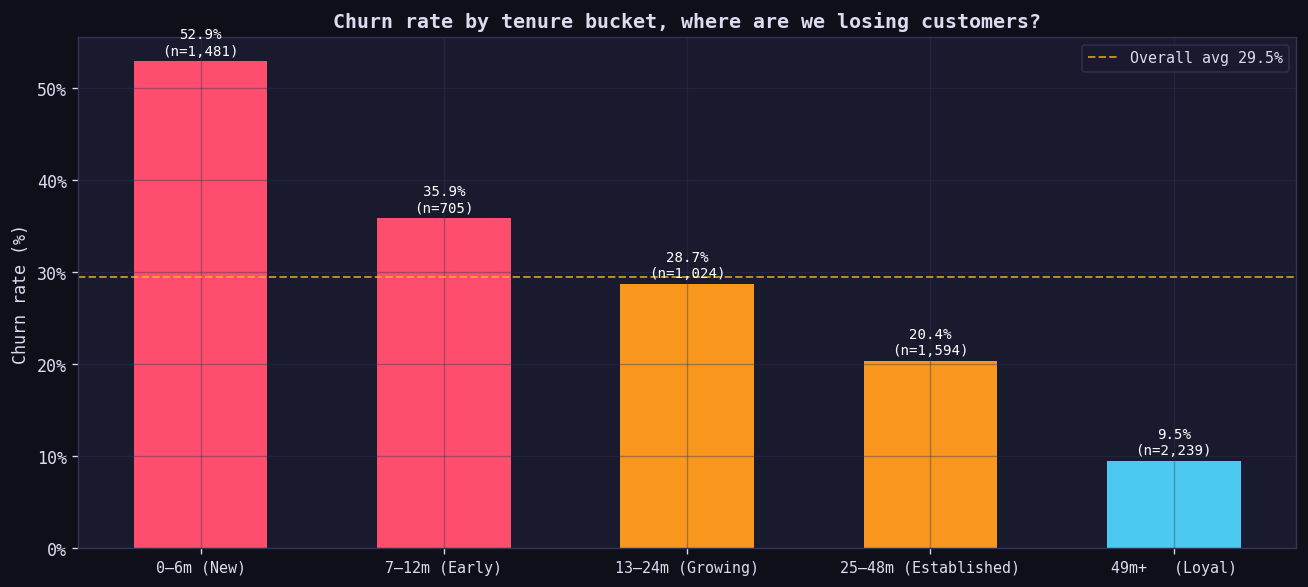

In [20]:
q_funnel = """
WITH tenure_buckets AS (
    SELECT
        customerID,
        Churn_bin,
        MonthlyCharges,
        tenure,
        CASE
            WHEN tenure BETWEEN 0  AND 6  THEN '0–6m (New)'
            WHEN tenure BETWEEN 7  AND 12 THEN '7–12m (Early)'
            WHEN tenure BETWEEN 13 AND 24 THEN '13–24m (Growing)'
            WHEN tenure BETWEEN 25 AND 48 THEN '25–48m (Established)'
            ELSE '49m+   (Loyal)'
        END AS tenure_bucket,
        CASE
            WHEN tenure BETWEEN 0 AND 6 THEN 1
            WHEN tenure BETWEEN 7 AND 12 THEN 2
            WHEN tenure BETWEEN 13 AND 24 THEN 3
            WHEN tenure BETWEEN 25 AND 48 THEN 4
            ELSE 5
        END AS bucket_order
    FROM customers)

SELECT
    bucket_order,
    tenure_bucket,
    COUNT(*) AS n_customers,
    SUM(Churn_bin) AS n_churned,
    ROUND(AVG(Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
    -- Cumulative retention: customers who made it to this stage
    ROUND(
        COUNT(*) * 100.0
        / SUM(COUNT(*)) OVER (ORDER BY bucket_order ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING),
    1) AS pct_of_base
FROM tenure_buckets
GROUP BY bucket_order, tenure_bucket
ORDER BY bucket_order"""

df_funnel = con.execute(q_funnel).df()
print(df_funnel[['tenure_bucket','n_customers','n_churned', 'churn_rate_pct','avg_monthly']].to_string(index=False))

# Funnel chart 
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(df_funnel))

bars = ax.bar(x, df_funnel['churn_rate_pct'],
               color=[PALETTE['churn'] if r > 30 else
                      PALETTE['accent'] if r > 15 else
                      PALETTE['no_churn']
                      for r in df_funnel['churn_rate_pct']], edgecolor='none', width=0.55)

ax.set_xticks(list(x))
ax.set_xticklabels(df_funnel['tenure_bucket'], fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn rate by tenure bucket, where are we losing customers?', fontweight='bold', fontsize=12)
ax.set_ylabel('Churn rate (%)')

for bar, (_, row) in zip(bars, df_funnel.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f"{row['churn_rate_pct']:.1f}%\n(n={row['n_customers']:,})", ha='center', va='bottom', fontsize=8.5, color='white')

ax.axhline(df_funnel['churn_rate_pct'].mean(), color=PALETTE['yellow'], linestyle='--', linewidth=1.2, alpha=0.7, label=f"Overall avg {df_funnel['churn_rate_pct'].mean():.1f}%")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('exports/02_churn_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

### Segment Performance - Contract x Internet Service

-> Business question: Which combination of contract type and internet service has the worst churn problem? Where is the intersection of high volume AND high churn rate?

-> Decision it informs: Product team prioritization, which customer segment to fix first.

      Contract InternetService  n_customers  n_churned  churn_rate_pct  avg_monthly  priority_score  revenue_at_risk_6m
Month-to-month     Fiber optic         2128     1162.0            54.6        87.02           47.52            602892.0
      One year     Fiber optic          539      104.0            19.3        98.78           19.06             63432.0
Month-to-month             DSL         1223      394.0            32.2        50.22           16.18            110203.0
      Two year     Fiber optic          429       31.0             7.2       104.57            7.56             19477.0
      One year             DSL          570       53.0             9.3        61.40            5.71             20138.0
Month-to-month              No          524       99.0            18.9        20.41            3.86             11987.0
      Two year             DSL          628       12.0             1.9        70.46            1.35              4834.0
      One year              No          

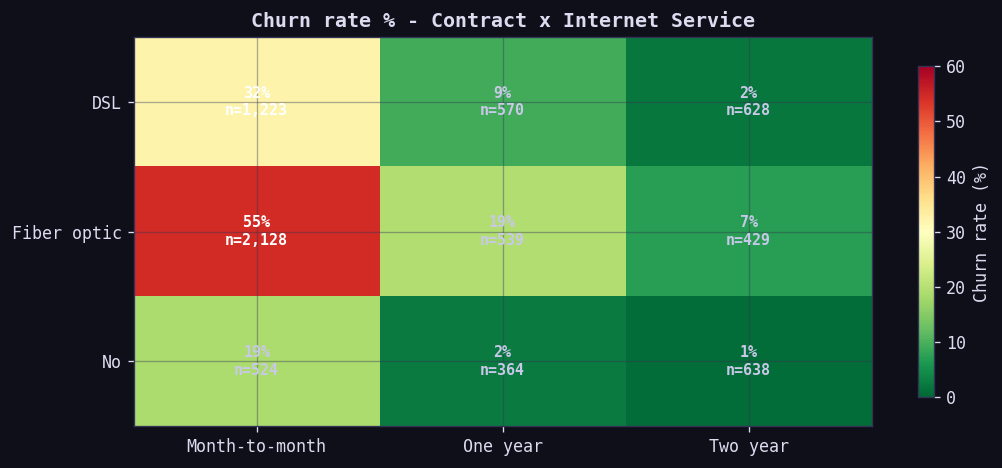

In [21]:
q_segment = """
SELECT
    Contract,
    InternetService,
    COUNT(*) AS n_customers,
    SUM(Churn_bin) AS n_churned,
    ROUND(AVG(Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
    -- Risk score: churn_rate x avg_revenue (high = high priority)
    ROUND(AVG(Churn_bin) * AVG(MonthlyCharges), 2) AS priority_score,
    ROUND(SUM(Churn_bin * MonthlyCharges * 6), 0)  AS revenue_at_risk_6m
FROM customers
GROUP BY Contract, InternetService
HAVING COUNT(*) >= 30
ORDER BY priority_score DESC"""

df_seg = con.execute(q_segment).df()
print(df_seg.to_string(index=False))

# Heatmap: churn rate by contract × internet 
pivot = df_seg.pivot_table(values='churn_rate_pct', index='InternetService', columns='Contract', aggfunc='first').fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', vmin=0, vmax=60, aspect='auto')
plt.colorbar(im, ax=ax, label='Churn rate (%)', shrink=0.85)

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_title('Churn rate % - Contract x Internet Service', fontweight='bold', fontsize=12)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        n_row = df_seg[(df_seg['InternetService'] == pivot.index[i]) &
            (df_seg['Contract'] == pivot.columns[j])]['n_customers'].values
        n_str = f"\nn={n_row[0]:,}" if len(n_row) > 0 else ''
        color = 'white' if val > 30 else '#c8c8e8'
        ax.text(j, i, f'{val:.0f}%{n_str}', ha='center', va='center', color=color, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('exports/03_segment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Cohort Analysis - Month-to-month Customers by Tenure

-> Business question: Among the highest-risk segment (month-to-month), when exactly do customers churn? Is there a critical window?

-> Decision it informs: When to trigger retention interventions. If churn peaks at month 3, the campaign needs to fire at month 2.

 months_as_customer  n_at_this_tenure  churned  churn_rate_pct  cumulative_churn_pct
                  1               604    380.0            62.9                 10.08
                  2               230    121.0            52.6                 13.29
                  3               191     94.0            49.2                 15.78
                  4               165     82.0            49.7                 17.96
                  5               128     63.0            49.2                 19.63
                  6                95     40.0            42.1                 20.69
                  7               113     50.0            44.2                 22.02
                  8               101     41.0            40.6                 23.10
                  9               105     45.0            42.9                 24.30
                 10                96     45.0            46.9                 25.49
                 11                80     30.0            37.5   

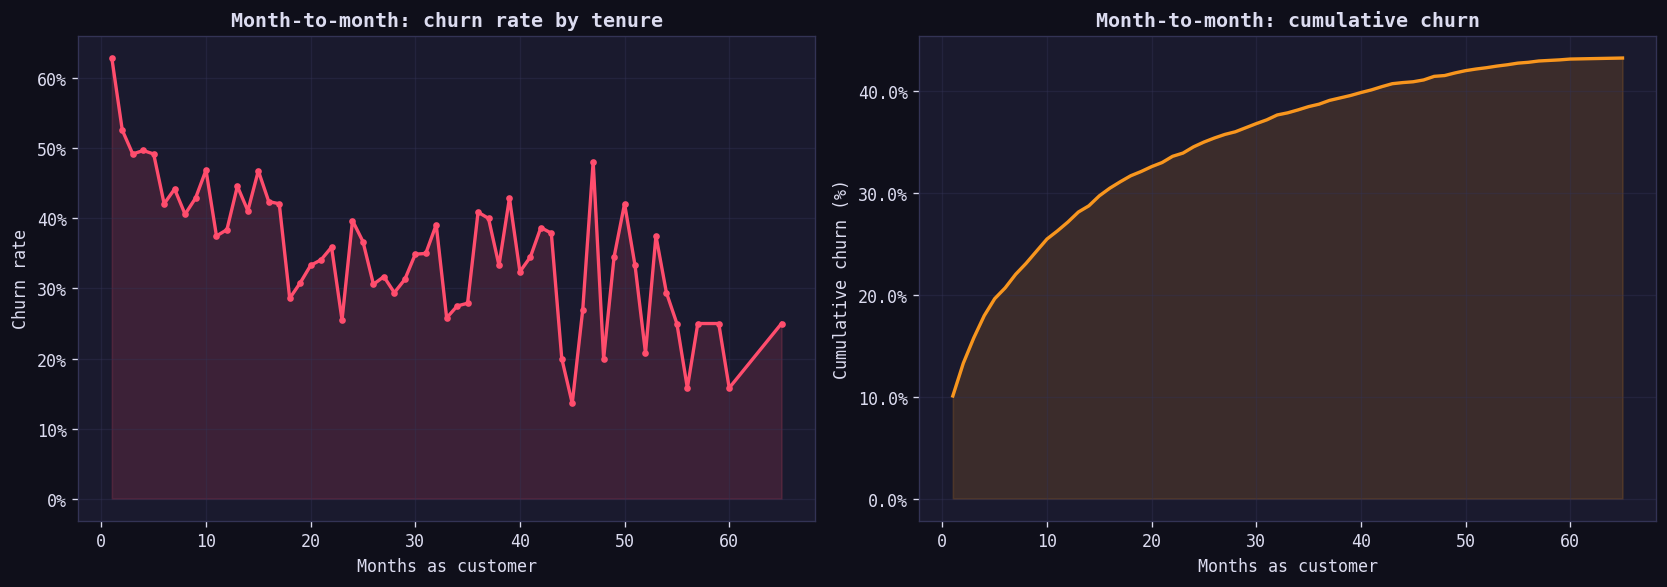

In [22]:
q_cohort = """
WITH mtm AS (
    SELECT
        tenure,
        Churn_bin,
        MonthlyCharges,
        -- Rolling window: customers surviving to month N
        COUNT(*) OVER (ORDER BY tenure DESC) AS still_active_at_month
    FROM customers
    WHERE Contract = 'Month-to-month')

SELECT
    tenure AS months_as_customer,
    COUNT(*) AS n_at_this_tenure,
    SUM(Churn_bin) AS churned,
    ROUND(AVG(Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
    -- Cumulative churn: % of original cohort lost by this tenure
    ROUND(
        SUM(SUM(Churn_bin)) OVER (ORDER BY tenure) * 100.0
        / SUM(COUNT(*)) OVER (), 2) AS cumulative_churn_pct
FROM mtm
GROUP BY tenure
HAVING COUNT(*) >= 15
ORDER BY tenure"""

df_cohort = con.execute(q_cohort).df()
print(df_cohort[['months_as_customer', 'n_at_this_tenure', 'churned', 'churn_rate_pct', 'cumulative_churn_pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly churn rate
axes[0].plot(df_cohort['months_as_customer'], df_cohort['churn_rate_pct'], color=PALETTE['churn'], linewidth=2, marker='o', markersize=3)
axes[0].fill_between(df_cohort['months_as_customer'], df_cohort['churn_rate_pct'], alpha=0.15, color=PALETTE['churn'])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xlabel('Months as customer')
axes[0].set_ylabel('Churn rate')
axes[0].set_title('Month-to-month: churn rate by tenure', fontweight='bold')

# Cumulative churn
axes[1].plot(df_cohort['months_as_customer'], df_cohort['cumulative_churn_pct'], color=PALETTE['accent'], linewidth=2)
axes[1].fill_between(df_cohort['months_as_customer'], df_cohort['cumulative_churn_pct'], alpha=0.15, color=PALETTE['accent'])

# Mark 50% cumulative churn point
half = df_cohort[df_cohort['cumulative_churn_pct'] >= 50].head(1)
if len(half) > 0:
    m50 = half['months_as_customer'].iloc[0]
    axes[1].axvline(m50, color=PALETTE['churn'], linestyle='--', alpha=0.7)
    axes[1].axhline(50, color=PALETTE['churn'], linestyle='--', alpha=0.7)
    axes[1].text(m50 + 0.5, 45, f'50% churned\nby month {m50}', color=PALETTE['churn'], fontsize=9)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlabel('Months as customer')
axes[1].set_ylabel('Cumulative churn (%)')
axes[1].set_title('Month-to-month: cumulative churn', fontweight='bold')

plt.tight_layout()
plt.savefig('exports/04_cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Payment Method - Auto-Pay as a Retention Lever

-> Business question: Does automatic payment actually reduce churn, or is it just correlated with other factors?

-> Decision it informs: Whether to invest in an auto-pay enrollment campaign. If auto-pay reduces churn by X%, what's the ROI of a $5 incentive to enroll?

In [23]:
q_autopay = """
WITH payment_groups AS (
    SELECT
        customerID,
        Churn_bin,
        MonthlyCharges,
        tenure,
        Contract,
        PaymentMethod,
        CASE
            WHEN PaymentMethod IN ('Bank transfer (automatic)', 'Credit card (automatic)')
            THEN 'Auto-pay'
            ELSE 'Manual payment'
        END AS payment_type
    FROM customers)

SELECT
    payment_type,
    Contract,
    COUNT(*) AS n_customers,
    SUM(Churn_bin) AS n_churned,
    ROUND(AVG(Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
    ROUND(AVG(tenure), 1) AS avg_tenure_months,
    -- Lift: how much lower is churn vs the segment average
    ROUND(
        AVG(Churn_bin) * 100
        - AVG(AVG(Churn_bin) * 100) OVER (PARTITION BY Contract), 1) AS lift_vs_contract_avg
FROM payment_groups
GROUP BY payment_type, Contract
ORDER BY Contract, churn_rate_pct DESC"""

df_pay = con.execute(q_autopay).df()
print(df_pay.to_string(index=False))

print("\n Auto-pay ROI estimate")
mtm_auto = df_pay[(df_pay['Contract']=='Month-to-month') & (df_pay['payment_type']=='Auto-pay')]
mtm_manual = df_pay[(df_pay['Contract']=='Month-to-month') & (df_pay['payment_type']=='Manual payment')]

if len(mtm_auto) > 0 and len(mtm_manual) > 0:
    lift_pct = mtm_manual['churn_rate_pct'].iloc[0] - mtm_auto['churn_rate_pct'].iloc[0]
    avg_monthly = mtm_manual['avg_monthly'].iloc[0]
    n_manual = mtm_manual['n_customers'].iloc[0]
    saved_if_converted = n_manual * (lift_pct/100) * avg_monthly * 6
    cost_of_incentive = n_manual * 5  # $5 to enroll
    roi_autopay_campaign = saved_if_converted - cost_of_incentive
    print(f"Churn rate lift from auto-pay (month-to-month): {lift_pct:.1f} pp")
    print(f"Revenue saved if all {n_manual:,} manual payers convert: ${saved_if_converted:,.0f}")
    print(f"Cost of $5 enrollment incentive: ${cost_of_incentive:,.0f}")
    print(f"Net ROI of auto-pay campaign: ${roi_autopay_campaign:,.0f}")

  payment_type       Contract  n_customers  n_churned  churn_rate_pct  avg_monthly  avg_tenure_months  lift_vs_contract_avg
Manual payment Month-to-month         2743     1276.0            46.5        65.57               15.4                   6.5
      Auto-pay Month-to-month         1132      379.0            33.5        68.41               24.4                  -6.5
Manual payment       One year          684       87.0            12.7        61.96               37.8                   1.4
      Auto-pay       One year          789       79.0            10.0        67.73               45.7                  -1.4
Manual payment       Two year          550       16.0             2.9        52.56               48.5                   0.1
      Auto-pay       Two year         1145       32.0             2.8        64.71               60.7                  -0.1

 Auto-pay ROI estimate
Churn rate lift from auto-pay (month-to-month): 13.0 pp
Revenue saved if all 2,743 manual payers convert: $1

### Service Bundle Analysis - The 3-4 Service Anomaly

-> Business question: Is there a non-obvious relationship between number of services and churn? The physics model flags customers with 3–4 services as higher risk than expected, does the SQL confirm this?

-> Decision it informs: Whether to redesign bundle pricing for the 3–4 service tier, or add a loyalty lock-in at that point.

 n_services  n_customers  n_churned  churn_rate_pct  avg_monthly  revenue_at_risk_6m
          0           80       35.0            43.8        24.90              5216.0
          1         1701      359.0            21.1        30.08             98541.0
          2         1188      390.0            32.8        51.13            154489.0
          3          965      352.0            36.5        69.36            162152.0
          4          922      289.0            31.3        78.73            150431.0
          5          908      232.0            25.6        86.31            132146.0
          6          676      152.0            22.5        93.64             93142.0
          7          395       49.0            12.4        99.43             31176.0
          8          208       11.0             5.3       104.63              7493.0


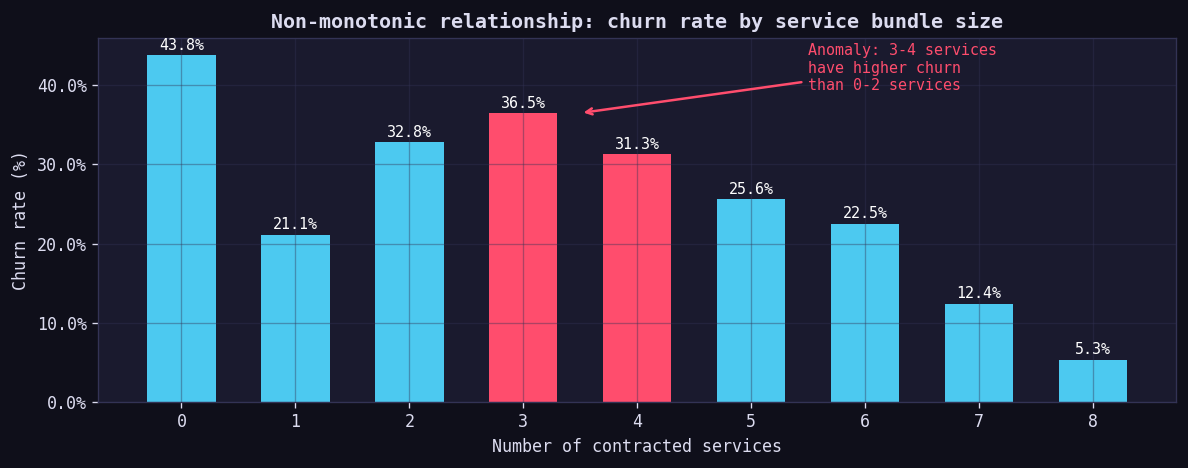

In [24]:
q_services = """
WITH service_count AS (
    SELECT
        customerID,
        Churn_bin,
        MonthlyCharges,
        Contract,
        -- Count active services
        COALESCE(num_services, 0) AS n_services
    FROM customers)

SELECT
    n_services,
    COUNT(*) AS n_customers,
    SUM(Churn_bin) AS n_churned,
    ROUND(AVG(Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
    ROUND(SUM(Churn_bin * MonthlyCharges * 6), 0) AS revenue_at_risk_6m
FROM service_count
GROUP BY n_services
HAVING COUNT(*) >= 20
ORDER BY n_services"""

df_svc = con.execute(q_services).df()
print(df_svc.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors_svc = [PALETTE['churn'] if (3 <= n <= 4) else PALETTE['no_churn']
              for n in df_svc['n_services']]
ax.bar(df_svc['n_services'], df_svc['churn_rate_pct'], color=colors_svc, edgecolor='none', width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Number of contracted services')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Non-monotonic relationship: churn rate by service bundle size', fontweight='bold')
ax.set_xticks(df_svc['n_services'])

for bar, val in zip(ax.patches, df_svc['churn_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='white')

ax.annotate('Anomaly: 3-4 services\nhave higher churn\nthan 0-2 services',
            xy=(3.5, df_svc[df_svc['n_services'].isin([3,4])]['churn_rate_pct'].max()), xytext=(5.5, df_svc['churn_rate_pct'].max() * 0.9),
            arrowprops=dict(arrowstyle='->', color=PALETTE['churn'], lw=1.5), color=PALETTE['churn'], fontsize=9)

plt.tight_layout()
plt.savefig('exports/05_service_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

### Early Warning Signals - Leading Indicators

-> Business question: What characteristics distinguish customers who churn in their first 12 months vs those who stay long-term? Can we flag them earlier?

-> Decision it informs: Onboarding strategy, which signals to monitor in the first 6 months.

In [25]:
q_early = """
WITH early_churners AS (
    SELECT
        customerID,
        Churn_bin,
        tenure,
        MonthlyCharges,
        Contract,
        InternetService,
        PaymentMethod,
        SeniorCitizen,
        CASE
            WHEN Churn_bin = 1 AND tenure <= 12 THEN 'Early churner (≤12m)'
            WHEN Churn_bin = 1 AND tenure >  12 THEN 'Late churner (>12m)'
            ELSE 'Retained'
        END AS customer_type
    FROM customers)

SELECT
    customer_type,
    COUNT(*) AS n_customers,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
    ROUND(AVG(tenure), 1) AS avg_tenure,
    ROUND(AVG(CASE WHEN Contract = 'Month-to-month' THEN 1.0 ELSE 0 END)*100, 1) AS pct_month_to_month,
    ROUND(AVG(CASE WHEN InternetService = 'Fiber optic' THEN 1.0 ELSE 0 END)*100, 1) AS pct_fiber,
    ROUND(AVG(CASE WHEN PaymentMethod IN
        ('Bank transfer (automatic)','Credit card (automatic)')
        THEN 1.0 ELSE 0 END)*100, 1) AS pct_auto_pay,
    ROUND(AVG(SeniorCitizen)*100, 1) AS pct_senior
FROM early_churners
GROUP BY customer_type
ORDER BY customer_type"""

df_early = con.execute(q_early).df()
print(df_early.to_string(index=False))

print("\n Key differences: early churners vs retained")
early = df_early[df_early['customer_type'].str.contains('Early')]
retained = df_early[df_early['customer_type'].str.contains('Retained')]
if len(early) > 0 and len(retained) > 0:
    for col, label in [('pct_month_to_month','Month-to-month'), ('pct_fiber','Fiber optic'), ('avg_monthly','Avg monthly charges'), ('pct_auto_pay','Auto-pay')]:
        diff = early[col].iloc[0] - retained[col].iloc[0]
        sign = '+' if diff > 0 else ''
        print(f" {label:30s}: {sign}{diff:.1f} pp vs retained")

       customer_type  n_customers  avg_monthly  avg_tenure  pct_month_to_month  pct_fiber  pct_auto_pay  pct_senior
Early churner (≤12m)         1037        66.49         4.0                98.7       62.2          17.7        20.9
 Late churner (>12m)          832        84.35        35.4                75.8       78.4          36.8        31.1
            Retained         5174        61.27        37.6                42.9       34.8          49.8        12.9

 Key differences: early churners vs retained
 Month-to-month                : +55.8 pp vs retained
 Fiber optic                   : +27.4 pp vs retained
 Avg monthly charges           : +5.2 pp vs retained
 Auto-pay                      : -32.1 pp vs retained


### Campaign Targeting - The Query a CRM Team Runs Daily

-> Business question: Which customers should we contact today?   
This is the operational output: a ranked list of customers with their risk profile, recommended action, and expected value of intervention, ready to feed into a CRM system

-> Decision it informs: Daily retention campaign execution.

In [26]:
q_targeting = """
WITH customer_scores AS (
    SELECT
        customerID,
        Contract,
        InternetService,
        MonthlyCharges,
        tenure,
        Churn_bin,
        PaymentMethod,
        -- Risk score: proxy for P(churn) using observable features
        ROUND(
            0.4 * CASE Contract
                    WHEN 'Month-to-month' THEN 1.0
                    WHEN 'One year' THEN 0.3
                    ELSE 0.05
                  END
            + 0.2 * CASE WHEN InternetService = 'Fiber optic' THEN 1.0 ELSE 0.3 END
            + 0.2 * CASE WHEN tenure < 12 THEN 1.0
                         WHEN tenure < 24 THEN 0.6
                         ELSE 0.2 END
            + 0.2 * CASE WHEN PaymentMethod IN
                ('Bank transfer (automatic)','Credit card (automatic)')
                THEN 0.2 ELSE 0.8 END, 3) AS risk_score,
        -- Expected value of intervention
        MonthlyCharges * 6 * 0.30 AS expected_revenue_saved,
        -- Action recommendation
        CASE
            WHEN Contract = 'Month-to-month' AND tenure < 12 AND MonthlyCharges > 70
                THEN 'Immediate: discount + contract upgrade offer'
            WHEN Contract = 'Month-to-month' AND tenure BETWEEN 12 AND 24
                THEN 'Proactive: loyalty reward + annual plan'
            WHEN Contract = 'Month-to-month' AND InternetService = 'Fiber optic'
                THEN 'Check service quality + offer tech support'
            WHEN PaymentMethod IN ('Electronic check','Mailed check')
                THEN 'Auto-pay enrollment incentive ($5 credit)'
            ELSE 'Monitor — low priority'
        END AS recommended_action,
        -- Net ROI of intervention
        ROUND(MonthlyCharges * 6 * 0.30 - 25, 0) AS net_roi_if_saved
    FROM customers)

SELECT
    customerID,
    Contract,
    InternetService,
    ROUND(MonthlyCharges, 0) AS monthly,
    tenure AS tenure_months,
    risk_score,
    ROUND(expected_revenue_saved, 0) AS expected_saved,
    net_roi_if_saved,
    recommended_action
FROM customer_scores
WHERE risk_score >= 0.65
  AND net_roi_if_saved > 0   -- Only contact if intervention is ROI-positive
ORDER BY risk_score DESC, expected_revenue_saved DESC
LIMIT 20 """

df_target = con.execute(q_targeting).df()
print(f"Top 20 customers to contact today (from {len(con.execute(q_targeting.replace('LIMIT 20','').replace('ORDER BY risk_score DESC, expected_revenue_saved DESC','')).df()):,} flagged):")
print(df_target[['customerID','monthly','tenure_months','risk_score', 'expected_saved','net_roi_if_saved','recommended_action']].to_string(index=False))

Top 20 customers to contact today (from 3,587 flagged):
customerID  monthly  tenure_months  risk_score  expected_saved  net_roi_if_saved                           recommended_action
3292-PBZEJ    111.0             11        0.96           201.0             176.0 Immediate: discount + contract upgrade offer
9851-KIELU    110.0             10        0.96           198.0             173.0 Immediate: discount + contract upgrade offer
5760-IFJOZ    108.0              3        0.96           194.0             169.0 Immediate: discount + contract upgrade offer
2081-VEYEH    108.0              3        0.96           194.0             169.0 Immediate: discount + contract upgrade offer
1400-MMYXY    106.0              3        0.96           191.0             166.0 Immediate: discount + contract upgrade offer
3389-YGYAI    106.0              8        0.96           190.0             165.0 Immediate: discount + contract upgrade offer
6734-GMPVK    105.0              5        0.96           190.0

### Window Functions - Percentile Ranking by Segment

-> Business question: For each contract type, what's the distribution of monthly charges, and where does a given customer rank?


In [27]:
q_window = """
WITH ranked AS (
    SELECT
        customerID,
        Contract,
        MonthlyCharges,
        tenure,
        Churn_bin,
        -- Percentile rank within contract type
        ROUND(PERCENT_RANK() OVER (
            PARTITION BY Contract
            ORDER BY MonthlyCharges) * 100, 1) AS charge_percentile,
        -- Quartile within contract type
        NTILE(4) OVER (
            PARTITION BY Contract
            ORDER BY MonthlyCharges) AS charge_quartile,
        -- Running average churn rate by tenure (within contract)
        ROUND(AVG(Churn_bin) OVER (
            PARTITION BY Contract
            ORDER BY tenure
            ROWS BETWEEN 5 PRECEDING AND 5 FOLLOWING) * 100, 1) AS rolling_churn_rate,
        -- Lag: previous month's charge (simulated from next customer)
        LAG(MonthlyCharges) OVER (PARTITION BY Contract ORDER BY tenure) AS prev_charge,
        LEAD(MonthlyCharges) OVER (PARTITION BY Contract ORDER BY tenure) AS next_charge
    FROM customers)

SELECT
    Contract,
    charge_quartile AS quartile,
    COUNT(*) AS n_customers,
    ROUND(MIN(MonthlyCharges), 0) AS min_charge,
    ROUND(MAX(MonthlyCharges), 0) AS max_charge,
    ROUND(AVG(MonthlyCharges), 0) AS avg_charge,
    ROUND(AVG(Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(rolling_churn_rate), 1) AS rolling_churn_rate_avg
FROM ranked
GROUP BY Contract, charge_quartile
ORDER BY Contract, charge_quartile"""

df_window = con.execute(q_window).df()
print(df_window.to_string(index=False))
print("\nWindow functions used: PERCENT_RANK, NTILE, AVG (rolling), LAG, LEAD")

      Contract  quartile  n_customers  min_charge  max_charge  avg_charge  churn_rate_pct  rolling_churn_rate_avg
Month-to-month         1          969        19.0        46.0        28.0            29.2                    37.4
Month-to-month         2          969        46.0        73.0        60.0            35.7                    34.3
Month-to-month         3          969        73.0        89.0        80.0            54.0                    53.4
Month-to-month         4          968        89.0       117.0        97.0            52.0                    45.8
      One year         1          369        18.0        27.0        21.0             2.7                     9.5
      One year         2          368        29.0        69.0        54.0             7.9                    10.7
      One year         3          368        69.0        95.0        82.0            11.7                    11.6
      One year         4          368        95.0       119.0       104.0            22.

### Summary - Business Findings

In [28]:
summary_q = """
SELECT
    COUNT(*) AS total_customers,
    ROUND(AVG(Churn_bin) * 100, 1) AS overall_churn_rate_pct,
    ROUND(SUM(Churn_bin * MonthlyCharges * 6), 0) AS total_revenue_at_risk_6m,
    ROUND(AVG(CASE WHEN Contract='Month-to-month' THEN Churn_bin END)*100,1) AS mtm_churn_rate,
    ROUND(AVG(CASE WHEN Contract='Two year' THEN Churn_bin END)*100,1) AS two_year_churn_rate,
    ROUND(AVG(CASE WHEN PaymentMethod IN
        ('Bank transfer (automatic)','Credit card (automatic)')
        THEN Churn_bin END)*100,1) AS auto_pay_churn_rate,
    ROUND(AVG(CASE WHEN PaymentMethod NOT IN
        ('Bank transfer (automatic)','Credit card (automatic)')
        THEN Churn_bin END)*100,1) AS manual_pay_churn_rate,
    SUM(CASE WHEN Churn_bin=1 AND tenure<=12 THEN 1 ELSE 0 END) AS early_churners_count
FROM customers"""

s = con.execute(summary_q).df().iloc[0]

print("")
print("SQL ANALYSIS SUMMARY")
print()
print(f" Dataset : {s['total_customers']:,} customers")
print(f" Overall churn : {s['overall_churn_rate_pct']:.1f}%")
print(f" Revenue at risk : ${s['total_revenue_at_risk_6m']:,.0f} (6-month window)")
print("")
print("CONTRACT EFFECT")
print(f" Month-to-month  : {s['mtm_churn_rate']:.1f}% churn")
print(f" Two-year : {s['two_year_churn_rate']:.1f}% churn")
print(f" -> Contract type explains {s['mtm_churn_rate']/s['two_year_churn_rate']:.1f}× more churn")
print("")
print(" PAYMENT EFFECT")
print(f" Auto-pay : {s['auto_pay_churn_rate']:.1f}% churn")
print(f" Manual payment : {s['manual_pay_churn_rate']:.1f}% churn")
lift = s['manual_pay_churn_rate'] - s['auto_pay_churn_rate']
print(f" Auto-pay reduces churn by {lift:.1f} pp - strong retention lever")
print("")
print(" EARLY CHURN")
print(f" Customers who churned in first 12 months: {s['early_churners_count']:,}")
print(f" -> {s['early_churners_count']/s['total_customers']*100:.1f}% of base lost in year 1")
print("")

print("\nSQL techniques used in this notebook:")
for t in [
    "CTEs (WITH clause)",
    "Window functions: PERCENT_RANK, NTILE, AVG rolling, LAG, LEAD",
    "Conditional aggregation: SUM(CASE WHEN ...)",
    "Running totals: SUM() OVER (ORDER BY)",
    "HAVING clause for segment filtering",
    "Derived metrics: priority score, net ROI, revenue at risk",
    "Self-referencing window: ROWS BETWEEN N PRECEDING AND N FOLLOWING",]:
    print(f" OK {t}")


SQL ANALYSIS SUMMARY

 Dataset : 7,043.0 customers
 Overall churn : 26.5%
 Revenue at risk : $834,785 (6-month window)

CONTRACT EFFECT
 Month-to-month  : 42.7% churn
 Two-year : 2.8% churn
 -> Contract type explains 15.3× more churn

 PAYMENT EFFECT
 Auto-pay : 16.0% churn
 Manual payment : 34.7% churn
 Auto-pay reduces churn by 18.7 pp - strong retention lever

 EARLY CHURN
 Customers who churned in first 12 months: 1,037.0
 -> 14.7% of base lost in year 1


SQL techniques used in this notebook:
 OK CTEs (WITH clause)
 OK Window functions: PERCENT_RANK, NTILE, AVG rolling, LAG, LEAD
 OK Conditional aggregation: SUM(CASE WHEN ...)
 OK Running totals: SUM() OVER (ORDER BY)
 OK HAVING clause for segment filtering
 OK Derived metrics: priority score, net ROI, revenue at risk
 OK Self-referencing window: ROWS BETWEEN N PRECEDING AND N FOLLOWING


### Multi-table JOINs - How this scales to production

-> Business question: In production, customer data lives in multiple tables. How do we replicate this analysis across a normalized schema?

-> This section simulates the three-table schema a real fintech would have:
- customers: demographics and contract info
- billing: monthly charges history
- services: product subscriptions

-> Decision it informs: Shows that the single-table queries above translate directly to production data warehouses (Snowflake, BigQuery, Redshift) with JOIN additions.

In [29]:
# Simulates a normalized 3-table schema
con.execute("""
    CREATE OR REPLACE TABLE dim_customers AS
    SELECT
        customerID,
        Contract,
        PaymentMethod,
        SeniorCitizen,
        Churn,
        Churn_bin
    FROM customers""")

con.execute("""
    CREATE OR REPLACE TABLE fact_billing AS
    SELECT
        customerID,
        tenure AS months_active,
        MonthlyCharges AS monthly_amount,
        TotalCharges AS total_amount
    FROM customers""")

con.execute("""
    CREATE OR REPLACE TABLE dim_services AS
    SELECT
        customerID,
        InternetService AS internet_tier,
        COALESCE(num_services, 0) AS n_services
    FROM customers""")

print("Tables created: dim_customers, fact_billing, dim_services")
for tbl in ['dim_customers', 'fact_billing', 'dim_services']:
    n = con.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    cols = [r[0] for r in con.execute(f'DESCRIBE {tbl}').fetchall()]
    print(f" {tbl}: {n:,} rows | columns: {cols}")

Tables created: dim_customers, fact_billing, dim_services
 dim_customers: 7,043 rows | columns: ['customerID', 'Contract', 'PaymentMethod', 'SeniorCitizen', 'Churn', 'Churn_bin']
 fact_billing: 7,043 rows | columns: ['customerID', 'months_active', 'monthly_amount', 'total_amount']
 dim_services: 7,043 rows | columns: ['customerID', 'internet_tier', 'n_services']


In [30]:
# JOIN 1: INNER JOIN - revenue at risk by contract + internet tier 
# Classic 3-table join: combine contract info, billing, and services to get the full picture per customer segment

q_join1 = """
SELECT
    c.Contract,
    s.internet_tier,
    COUNT(DISTINCT c.customerID) AS n_customers,
    SUM(c.Churn_bin) AS n_churned,
    ROUND(AVG(c.Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(b.monthly_amount), 2) AS avg_monthly,
    ROUND(SUM(c.Churn_bin * b.monthly_amount * 6), 0) AS revenue_at_risk_6m,
    ROUND(AVG(s.n_services), 1) AS avg_services
FROM dim_customers c
INNER JOIN fact_billing b ON c.customerID = b.customerID
INNER JOIN dim_services s ON c.customerID = s.customerID
GROUP BY c.Contract, s.internet_tier
HAVING COUNT(*) >= 30
ORDER BY revenue_at_risk_6m DESC
LIMIT 10"""

df_join1 = con.execute(q_join1).df()
print("INNER JOIN - Revenue at risk by Contract x Internet tier")
print(df_join1.to_string(index=False))

INNER JOIN - Revenue at risk by Contract x Internet tier
      Contract internet_tier  n_customers  n_churned  churn_rate_pct  avg_monthly  revenue_at_risk_6m  avg_services
Month-to-month   Fiber optic         2128     1162.0            54.6        87.02            602892.0           3.5
Month-to-month           DSL         1223      394.0            32.2        50.22            110203.0           2.5
      One year   Fiber optic          539      104.0            19.3        98.78             63432.0           5.3
      One year           DSL          570       53.0             9.3        61.40             20138.0           4.1
      Two year   Fiber optic          429       31.0             7.2       104.57             19477.0           6.3
Month-to-month            No          524       99.0            18.9        20.41             11987.0           1.1
      Two year           DSL          628       12.0             1.9        70.46              4834.0           5.6
      One year 

In [31]:
# JOIN 2: LEFT JOIN with aggregated subquery
# Pattern: pre-aggregate one table, then join - avoids row explosion

q_join2 = """
WITH billing_summary AS (
    -- Pre-aggregate billing per customer to avoid row explosion
    SELECT
        customerID,
        monthly_amount,
        total_amount,
        months_active,
        -- Charge volatility proxy: are they paying more than their average?
        CASE
            WHEN monthly_amount > total_amount / NULLIF(months_active, 0) * 1.1
            THEN 1 ELSE 0
        END AS is_high_recent_charge
    FROM fact_billing),

service_profile AS (
    SELECT
        customerID,
        n_services,
        CASE
            WHEN n_services >= 5 THEN 'Power user'
            WHEN n_services >= 3 THEN 'Mid user'
            ELSE 'Light user'
        END AS usage_tier
    FROM dim_services)
SELECT
    sp.usage_tier,
    c.Contract, 
    COUNT(*) AS n_customers,
    ROUND(AVG(c.Churn_bin) * 100, 1) AS churn_rate_pct,
    ROUND(AVG(b.monthly_amount), 2) AS avg_monthly,
    -- % of customers with a recent charge spike
    ROUND(AVG(b.is_high_recent_charge) * 100, 1) AS pct_charge_spike,
    ROUND(AVG(b.months_active), 1) AS avg_tenure
FROM dim_customers c
LEFT JOIN billing_summary b  ON c.customerID = b.customerID
LEFT JOIN service_profile sp ON c.customerID = sp.customerID
WHERE sp.usage_tier IS NOT NULL
GROUP BY sp.usage_tier, c.Contract
ORDER BY sp.usage_tier, churn_rate_pct DESC"""

df_join2 = con.execute(q_join2).df()
print("LEFT JOIN with pre-aggregated CTEs - churn by usage tier x contract")
print(df_join2.to_string(index=False))

LEFT JOIN with pre-aggregated CTEs - churn by usage tier x contract
usage_tier       Contract  n_customers  churn_rate_pct  avg_monthly  pct_charge_spike  avg_tenure
Light user Month-to-month         1850            41.1        47.14               6.7        10.3
Light user       One year          458             4.1        25.70               8.7        30.7
Light user       Two year          661             0.8        22.58               2.9        48.5
  Mid user Month-to-month         1327            44.8        77.75               2.9        20.9
  Mid user       One year          378            10.3        67.24               0.8        40.8
  Mid user       Two year          182             4.4        60.01               1.1        54.9
Power user Month-to-month          698            43.1        95.87               0.9        33.0
Power user       One year          637            17.0        92.04               0.2        50.9
Power user       Two year          852            

In [32]:
# JOIN 3: Self-join + window - customer ranking within peer group 
# Shows a customer's risk relative to similar customers (same contract + tier)

q_join3 = """
WITH customer_full AS (
    SELECT
        c.customerID,
        c.Contract,
        c.Churn_bin,
        b.monthly_amount,
        b.months_active,
        s.internet_tier,
        s.n_services
    FROM dim_customers c
    INNER JOIN fact_billing  b ON c.customerID = b.customerID
    INNER JOIN dim_services  s ON c.customerID = s.customerID),
peer_ranked AS (
    SELECT
        *,
        -- Rank within contract x internet tier peer group
        ROUND(PERCENT_RANK() OVER (
            PARTITION BY Contract, internet_tier
            ORDER BY monthly_amount) * 100, 1) AS charge_pct_in_peer_group,
        -- Z-score vs peer group
        ROUND(
            (monthly_amount - AVG(monthly_amount) OVER (PARTITION BY Contract, internet_tier))
            / NULLIF(STDDEV(monthly_amount) OVER (PARTITION BY Contract, internet_tier), 0), 2) AS charge_zscore,
        -- Peer group churn rate (excluding self via window)
        ROUND(AVG(Churn_bin) OVER (
            PARTITION BY Contract, internet_tier) * 100, 1) AS peer_churn_rate
    FROM customer_full)
SELECT
    customerID,
    Contract,
    internet_tier,
    ROUND(monthly_amount, 0) AS monthly,
    months_active AS tenure,
    charge_pct_in_peer_group AS charge_pct_rank,
    charge_zscore,
    peer_churn_rate,
    Churn_bin AS churned
FROM peer_ranked
WHERE Contract = 'Month-to-month'
  AND internet_tier = 'Fiber optic'
ORDER BY charge_zscore DESC
LIMIT 15"""

df_join3 = con.execute(q_join3).df()
print("3-table JOIN + window functions, customer ranking within peer group")
print("(Month-to-month Fiber customers ranked by charge vs peers)")
print(df_join3.to_string(index=False))
print("\nSQL patterns demonstrated in section 13:")
for p in [
    "CREATE TABLE AS SELECT (DDL)",
    "INNER JOIN across 3 tables",
    "LEFT JOIN with pre-aggregated CTE subquery",
    "Self-join equivalent via window PARTITION BY",
    "PERCENT_RANK() within peer group",
    "Z-score normalisation with STDDEV() window",
    "NULLIF() for safe division",
    "AVG() window for peer group rate",]:
    print(f' OK {p}')

3-table JOIN + window functions, customer ranking within peer group
(Month-to-month Fiber customers ranked by charge vs peers)
customerID       Contract internet_tier  monthly  tenure  charge_pct_rank  charge_zscore  peer_churn_rate  churned
2302-ANTDP Month-to-month   Fiber optic    117.0      48            100.0           2.72             54.6        1
8016-NCFVO Month-to-month   Fiber optic    117.0      55            100.0           2.63             54.6        0
9659-QEQSY Month-to-month   Fiber optic    116.0      45             99.9           2.56             54.6        0
4361-BKAXE Month-to-month   Fiber optic    115.0      41             99.9           2.45             54.6        1
6710-HSJRD Month-to-month   Fiber optic    114.0      61             99.8           2.42             54.6        0
9158-VCTQB Month-to-month   Fiber optic    114.0      41             99.8           2.37             54.6        1
7279-BUYWN Month-to-month   Fiber optic    113.0      41            